<a href="https://colab.research.google.com/github/ivanmm710x/machine-learning-titanic/blob/main/Machine_Learning_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Titanic/DataSet_Titanic.csv")


In [ ]:
df.head()


,Sobreviviente,Clase,Genero,Edad,HermEsp,PadHij
0,0,3,0,22.0,1,0
1,1,1,1,38.0,1,0
2,1,3,1,26.0,0,0
3,1,1,1,35.0,1,0
4,0,3,0,35.0,0,0


In [ ]:
# guardar en variable X los atributos predictores (todas las etiquetas excepto "Sobreviviente")
X = df.drop("Sobreviviente", axis=1)

# guardar en y la etiqueta a predecir ("Sobreviviente")
y = df.Sobreviviente


In [ ]:
# visualizar x
X.head()


,Clase,Genero,Edad,HermEsp,PadHij
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0


In [ ]:
# visualizar y
y.head()


,Sobreviviente
0,0
1,1
2,1
3,1
4,0


In [ ]:
# Creamos un objeto arbol
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)


In [ ]:
# entrenamos a la máquina
arbol.fit(X, y)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# Predecimos sobre nuestro set
pred_y = arbol.predict(X)


# Comaparamos con las etiquetas reales
print('Precision: ', accuracy_score(pred_y, y))


Precision:  0.8151260504201681


In [ ]:
# creamos una matriz de confusión
confusion_matrix(y, pred_y)


array([[372,  52],
       [ 80, 210]])

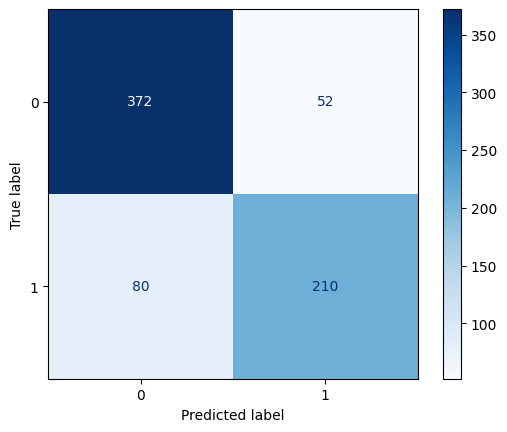

In [ ]:
# creamos un gráfico para la matriz de confusión
cm = confusion_matrix(y, pred_y)

disp = ConfusionMatrixDisplay(cm, display_labels = arbol.classes_)
disp.plot(cmap = plt.cm.Blues)

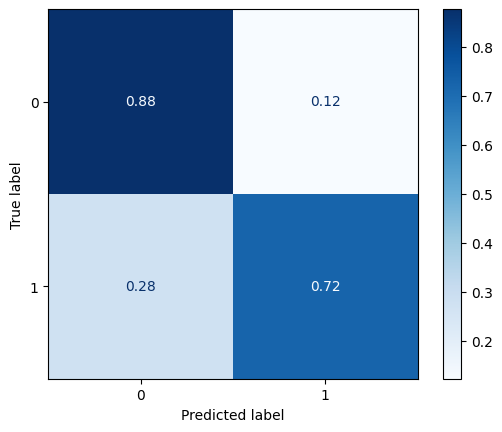

In [ ]:
# creamos un gráfico para la matriz de confusión normalizada
ConfusionMatrixDisplay.from_estimator(arbol, X, y, cmap=plt.cm.Blues, values_format='.2f', normalize='true')


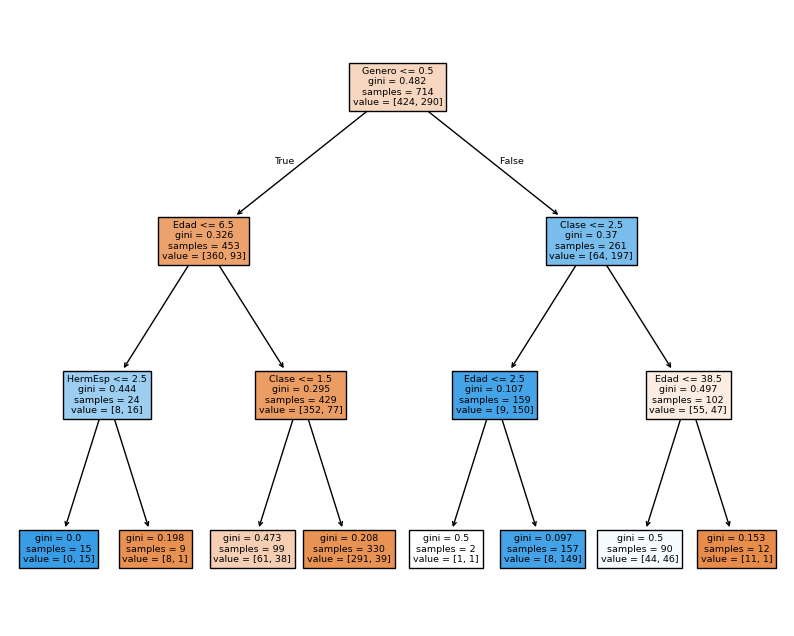

In [ ]:
# mostramos un árbol gráficamente
plt.figure(figsize=(10,8))
tree.plot_tree(arbol, filled=True, feature_names=X.columns)
plt.show()

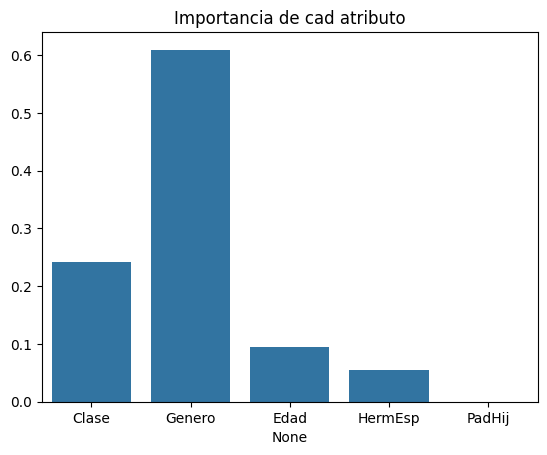

In [ ]:
# graficamos las importancias en un gráfico de barras
# creamos las variables x (importancias) e y (columnas)
importancias = arbol.feature_importances_
columnas = X.columns

# creamos el gráfico
sns.barplot(x=columnas, y=importancias)
plt.title('Importancia de cad atributo')
plt.show()
